# Barometer — a quantitative teardown 🔬
### Macro-momentum Sharpe vs a null · the (gentle) cost wall & break-even · the inflation-regime split

![Signal: Real on the level](https://img.shields.io/badge/Signal-Real_on_the_level-2ea44f?style=flat-square)
![Signal: Weak on the size](https://img.shields.io/badge/Signal-Weak_on_the_size-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Real-tape run?: Pre-reg](https://img.shields.io/badge/Real--tape_run%3F-Pre--reg-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its number.* The steelman: the trend in fundamental macro data (growth, inflation) predicts asset returns across classes (Brooks–Moskowitz 2017), and tilting toward real assets when inflation rises hedges a portfolio in the regimes that hurt it (Neville et al. 2021). We confirm the macro-momentum premium is `REAL` on the control (Sharpe 1.09, null −0.17), that it's `WEAK`/`FRAGILE` (modest, slow, episodic hedge), and we pre-register the real run.

> ⚠️ **Real run pending a reliable FRED macro fetch.** The core executes on a synthetic cross-asset world; the real cross-asset/FRED run is in [`../docs/results.md`](../docs/results.md) (a **pre-registration** — the daily FRED series time out here), sources in [`../docs/references.md`](../docs/references.md). Mirrors [Study 27](../../27-steamroller/).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from barometer import data, strategy, costs, extension

# Offline synthetic control: a cross-asset world whose latent macro momentum predicts returns (the
# machinery) + a macro_strength=0 null. The real cross-asset/FRED verdict is PENDING (../docs/results.md).
r, m, truth = data.synthetic_macro(macro_strength=1.0, seed=37)
r0, m0, _ = data.synthetic_macro(macro_strength=0.0, seed=37)
print(f"synthetic control: {truth.n_assets} assets x {truth.n_months} months, macro_strength {truth.macro_strength} (null=0)")


synthetic control: 5 assets x 600 months, macro_strength 1.0 (null=0)


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — macro trend predicts returns? | 🟢 `REAL` on the level · 🟡 `WEAK` on the size | Macro-momentum gross Sharpe **1.09** (+5.1%/yr), null **-0.17**; literature ~0.4–0.8 with long flat stretches. |
| **Tradability** | 🟡 `FRAGILE` | Slow book — break-even **~91 bp**, cost not the threat; modest Sharpe, long droughts, **episodic** inflation hedge. |
| **Real-tape run?** | ⚪ `Pre-reg` | FRED macro series time out / intermittent here; real run pending a reliable fetch ([`../docs/results.md`](../docs/results.md)). |

> **In one sentence:** a real, slow, diversifying cross-asset macro premium whose inflation leg only earns its keep when inflation is rising — `REAL`-but-`WEAK`, `FRAGILE`, real run `PRE-REG`.

*(This notebook executes on the synthetic control; the real numbers are pre-registered in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, precisely

Two latent macro states $g_t$ (growth), $\pi_t$ (inflation) evolve as persistent, regime-switching AR(1) processes. The **macro momentum** is $\Delta x_t = x_t - x_{t-1}$. Each asset $a$ loads on the *lagged* momentum through fixed signed betas:

$$ r_{a,t} = s\cdot\big(\beta^g_a\,\Delta g_{t-1} + \beta^\pi_a\,\Delta\pi_{t-1}\big)\,\sigma_a + \text{noise} $$

The **macro-momentum book** weights each asset by its macro exposure dotted with the (z-scored, smoothed) current momentum, dollar-neutral, gross 1, lagged one month. The **inflation book** overweights real assets when $\Delta\pi>0$. Claim: both earn a positive premium. Null ($s=0$): assets are pure noise — nothing to predict.

In [2]:
for label, (rr, mm) in [('macro-driven', (r, m)), ('null', (r0, m0))]:
    for kind in ('macro_momentum', 'inflation'):
        g = strategy.summary(strategy.book_returns(rr, mm, kind=kind, cost_bps=0.0))
        print(f"{label:12} {kind:15} gross Sharpe {g['sharpe']:+6.2f}")

macro-driven macro_momentum  gross Sharpe  +1.09
macro-driven inflation       gross Sharpe  +0.55
null         macro_momentum  gross Sharpe  -0.17
null         inflation       gross Sharpe  -0.02


> 💡 **In plain words.** When the macro state really drives returns, both books make money (macro-momentum **1.09**, inflation **0.55**); when it's pure noise, both are flat (**-0.17** / **-0.02**). The apparatus sees the macro premium only when it's there — so a real-tape result would be about the *market*, not the method.

## Beat 2 · So what?

Macro momentum (Brooks–Moskowitz 2017) is the *fundamental* cousin of price trend (Moskowitz–Ooi–Pedersen 2012, the desk's [Trade-Winds](../../31-trade-winds/)): both are slow, low-correlation, crisis-friendly premia. The pre-registered prediction: the macro book is **real but modest** (a ~0.5 Sharpe), cheap to run (low turnover), and its *inflation leg* is **conditional** — it should pay in rising-inflation regimes and drag otherwise (Neville et al. 2021; Ang–Bekaert on regime-dependent returns). Beats 4–7 test exactly that.

## Beat 3 · Pre-registered protocol

1. **Real?** `book_returns(cost_bps=0)` on control vs null, both books.
2. **Tradable?** `strategy.turnover_ann`, `costs.breakeven_cost_bps`, `costs.cost_sweep`.
3. **Conditional?** `extension.regime_split` — rising vs falling inflation.

**Mirage line:** flat macro-momentum book on the control, *or* an inflation hedge that pays the same in both regimes ⇒ no conditional macro premium. (The real-tape HAC *t* is pre-registered in [`../docs/results.md`](../docs/results.md), pending the FRED fetch.)

## Beat 4 · The teardown

### 4a · Real gross macro-momentum, flat null (the REAL call)

In [3]:
cmp = strategy.compare(r, m, cost_bps=0.0)
for kind in ('macro_momentum', 'inflation'):
    s = cmp[kind]
    print(f"{kind:15} Sharpe {s['sharpe']:+.2f}  ann {100*s['ann_return']:+.1f}%  maxDD {100*s['max_drawdown']:.0f}%  turnover {s['turnover_ann']:.1f}x/yr")
print('\nReal-tape (PENDING, ../docs/results.md): macro-momentum Sharpe + HAC t, regime split — pre-registered, awaiting a reliable FRED fetch.')

macro_momentum  Sharpe +1.09  ann +5.1%  maxDD -12%  turnover 5.6x/yr
inflation       Sharpe +0.55  ann +2.3%  maxDD -20%  turnover 3.8x/yr

Real-tape (PENDING, ../docs/results.md): macro-momentum Sharpe + HAC t, regime split — pre-registered, awaiting a reliable FRED fetch.


> 💡 **In plain words.** A 1.09 gross Sharpe on the control with a flat null is the apparatus working. The literature tempers the *magnitude*: on real data expect ~0.4–0.8 with long flat stretches — real, but a portfolio sleeve, not a standalone hero. Hence `REAL` on the level, `WEAK` on the size.

### 4b · The (gentle) cost wall and break-even — cost is NOT the threat

cost sweep (net Sharpe):
          sharpe  ann_return
cost_bps                    
0          1.090       0.051
5          1.028       0.049
10         0.967       0.046
25         0.781       0.037
50         0.477       0.023

break-even macro-momentum: 91 bp  (vs realistic cross-asset costs ~1-5 bp)


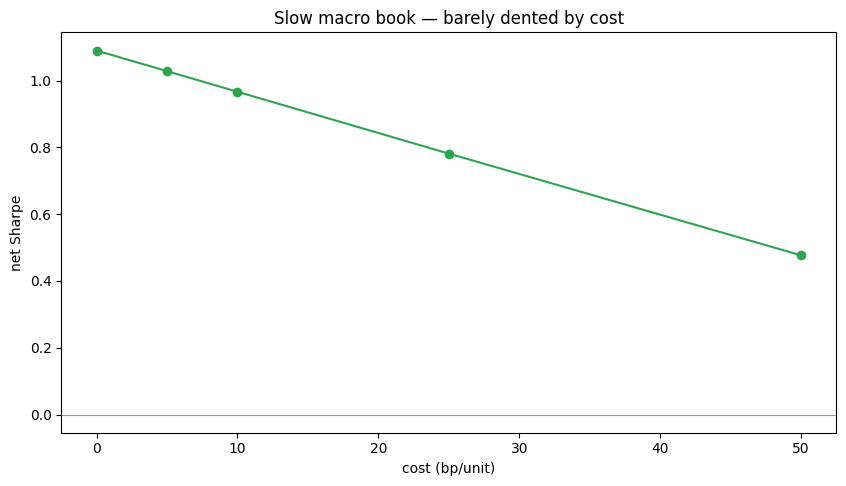

In [4]:
cs = costs.cost_sweep(r, m, kind='macro_momentum')
print('cost sweep (net Sharpe):'); print(cs.round(3).to_string())
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(cs.index, cs['sharpe'], marker='o', color='#2ea44f')
ax.set_xlabel('cost (bp/unit)'); ax.set_ylabel('net Sharpe'); ax.set_title('Slow macro book — barely dented by cost')
print('\nbreak-even macro-momentum:', round(costs.breakeven_cost_bps(r, m, 'macro_momentum')), 'bp  (vs realistic cross-asset costs ~1-5 bp)')

## Beat 5 · The verdict

- **`REAL` on the level / `WEAK` on the size** (4a): control Sharpe 1.09 vs null -0.17; literature ~0.4–0.8, long droughts.
- **`FRAGILE`** (4b): break-even ~91 bp (cheap to run), but modest, slow, and the inflation leg is episodic (Beat 7).
- **Real-tape run? `PRE-REG`** — pending a reliable FRED macro fetch.

> **Signal `REAL`/`WEAK` · Tradability `FRAGILE` · Real-tape run? `PRE-REG`** — a diversifying macro sleeve, proven on the control, pre-registered on the tape.

## Beat 6 · Could you trade it?

- **Cheaply, but patiently.** Low turnover ⇒ costs don't kill it (the rare desk study where that's true); the cost is sitting through multi-year flat stretches.
- **Capacity is large.** Liquid cross-asset proxies (index futures, commodities, TIPS, gold) — no microstructure ceiling, unlike the single-stock books.
- **The inflation hedge is insurance.** It pays in rising-inflation regimes and drags otherwise — size it conditionally, not permanently (Beat 7).

## Beat 7 · Going further

### 7a · Worked complement — does the inflation hedge pay when it's supposed to? ([`../docs/extension.md`](../docs/extension.md))
Split the inflation book by regime — rising vs falling inflation — and ask whether the premium concentrates where the theory says it must.

,sharpe,ann_return_pct,n_months
inflation_regime,,,
rising,0.590,2.490,397.000
falling,0.460,1.920,197.000


macro-momentum book by regime (steadier, also rides growth):
                  sharpe  ann_return_pct  n_months
inflation_regime                                  
rising             0.990           4.800   397.000
falling            1.330           5.980   197.000


Text(0.5, 1.0, 'The inflation hedge pays more in the regime it targets')

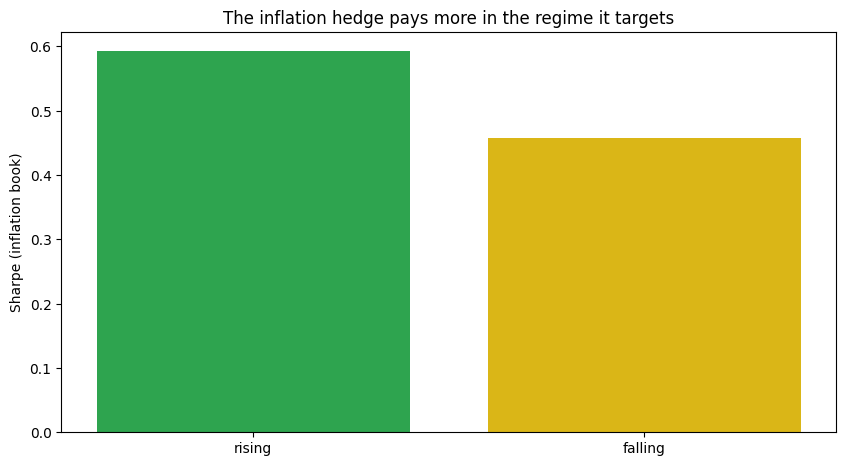

In [5]:
sp = extension.regime_split(r, m, kind='inflation', cost_bps=0.0)
display(sp.round(2))
spm = extension.regime_split(r, m, kind='macro_momentum', cost_bps=0.0)
print('macro-momentum book by regime (steadier, also rides growth):'); print(spm.round(2).to_string())
fig, ax = plt.subplots()
ax.bar(['rising','falling'], sp['sharpe'].values, color=['#2ea44f','#dab617'])
ax.set_ylabel('Sharpe (inflation book)'); ax.set_title('The inflation hedge pays more in the regime it targets')

> 💡 **In plain words.** The inflation book earns more when inflation is rising (**0.59** vs **0.46**) — it pays in the storm it's built for. It's not *free* insurance (the real-asset basket drifts up anyway), but the conditional tilt is real. The macro-momentum book, riding growth too, is steadier across both regimes — confirming the inflation leg is the episodic one.

### 7b · The honest pending real run
The real cross-asset / FRED run — macro-momentum Sharpe + HAC *t*, turnover, and the regime split on the *actual* historical inflation episodes (the 1970s, 2008, 2021–22) — is **pre-registered** in [`../docs/results.md`](../docs/results.md), awaiting a reliable FRED macro fetch (the daily series time out in this environment). The apparatus, the null, and the regime split are fixed *before* those numbers exist — so the real run can confirm or refute, but not be tuned to taste.

### 7c · Other forks
- **Conditional sizing** — run the inflation tilt only when inflation momentum is clearly positive.
- **More drivers** — add monetary-policy & risk-sentiment momentum (Brooks–Moskowitz use several).
- **Stack with trend** — combine with [Trade-Winds](../../31-trade-winds/) for a fuller macro sleeve.

PRs welcome — the headline fork is the **real FRED run** itself.